# UR10 Simple Reach — RTDE Control Loop

Deploy the trained 6-DOF reaching policy on a real UR10 (or URSim) via RTDE.

**Observation (18D):** `q[6], qd[6], tcp_pos[3], target_pos[3]`  
**Action (6D):** delta joint positions, scaled by `action_scale=0.04`  
**Control:** `ctrl_next = clip(ctrl_prev + action_scale * action, lowers, uppers)`

## 1 — Backend setup

In [1]:
import os
import platform
import subprocess

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

system = platform.system()
if system == "Darwin":
    os.environ["MUJOCO_GL"] = "glfw"
    os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
    print("macOS — MUJOCO_GL=glfw, JAX on CPU")
elif subprocess.run(["nvidia-smi"], capture_output=True).returncode == 0:
    os.environ["MUJOCO_GL"] = "egl"
    print("NVIDIA GPU detected — MUJOCO_GL=egl")
else:
    os.environ["MUJOCO_GL"] = "osmesa"
    os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")
    print("No GPU — MUJOCO_GL=osmesa, JAX on CPU")

macOS — MUJOCO_GL=glfw, JAX on CPU


## 2 — Imports

In [2]:
import json
import time

import jax
import matplotlib.pyplot as plt
import mediapy as media
import numpy as np

from URSim_RTDE_dependencies import URSimRTDESimpleReach

print("JAX devices:", jax.devices())

Failed to import warp: No module named 'warp'
Failed to import mujoco.mjx.third_party.mujoco_warp as mujoco_warp: No module named 'warp'
JAX devices: [CpuDevice(id=0)]


## 3 — Configuration

In [3]:
HOST = "127.0.0.1"          # URSim or real robot IP

# Paths
MODEL_PATH = "../../mujoco_playground/_src/manipulation/my_ur10/xmls/mjx_reach.xml"
POLICY_PATH = "../../evaluation/downloaded_policies/simple_reach_policy"

# Target position in world frame (meters) — must be within training workspace
# Training range: x=[0.3,0.8], y=[-0.4,0.4], z=[0.2,0.8]
TARGET_POS = np.array([0.5, 0.0, 0.5])

# Control loop settings (must match training: ctrl_dt=0.02 -> 50 Hz)
CONTROL_HZ = 50.0
ACTION_SCALE = 0.04
TIMEOUT_S = 10.0

# Start pose — "low_home" keyframe from mjx_reach.xml
Q_START = [0, -1.7, 2.25, -2.15, -1.5, -1.5]

# servoj parameters
LOOKAHEAD_TIME = 0.1
GAIN = 300

## 4 — Connect to robot & verify

In [4]:
robot = URSimRTDESimpleReach(host=HOST)
robot.connect()
robot.print_feedback()

q      = [0.9584, 2.3035, -0.1571, -0.5782, -2.9239, -3.3644]
qd     = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
tcp_xyz= [0.3729, 0.4682, -0.4612]


## 5 — Load policy & MuJoCo FK model

In [5]:
robot.load_policy_fn(policy_path=POLICY_PATH)
robot.init_fk_model(MODEL_PATH)

Loaded policy: obs=18, act=6
FK model loaded: tcp site id=1


## 6 — Verify policy in simulation (same as UR10_SimpleReach.ipynb chunk 10)

In [6]:
import mujoco
from mujoco_playground import registry

loaded_env = registry.load(robot._meta["env_name"])
jit_reset = jax.jit(loaded_env.reset)
jit_step  = jax.jit(loaded_env.step)

mj_model = mujoco.MjModel.from_xml_path(MODEL_PATH)
mj_data  = mujoco.MjData(mj_model)
renderer = mujoco.Renderer(mj_model, height=480, width=640)

cam = mujoco.MjvCamera()
cam.type      = mujoco.mjtCamera.mjCAMERA_FREE
cam.lookat[:] = [0.4, 0.0, 0.4]
cam.distance  = 1.8
cam.azimuth   = 130
cam.elevation = -20

state = jit_reset(jax.random.PRNGKey(42))

frames_sim = []
rewards_sim = []
for t in range(150):
    action = robot._policy_fn(state.obs)
    state = jit_step(state, action)
    rewards_sim.append(float(state.reward))

    mj_data.qpos[:]      = np.array(state.data.qpos)
    mj_data.qvel[:]      = np.array(state.data.qvel)
    mj_data.ctrl[:]      = np.array(state.data.ctrl)
    mj_data.mocap_pos[:] = np.array(state.data.mocap_pos)
    mujoco.mj_forward(mj_model, mj_data)

    if t % 2 == 0:
        renderer.update_scene(mj_data, camera=cam)
        frames_sim.append(renderer.render().copy())

    if float(state.done) > 0.0:
        print(f"Episode ended at step {t+1}")
        break

target_sim = np.array(state.obs[15:18])
tcp_sim = np.array(state.obs[12:15])
print(f"{len(frames_sim)} frames | Final dist: {np.linalg.norm(target_sim - tcp_sim)*100:.1f} cm | Reward: {sum(rewards_sim):.1f}")
media.show_video(frames_sim, fps=30, height=480)

75 frames | Final dist: 0.4 cm | Reward: 1141.7


This browser does not support the video tag.


## 7 — JIT warmup

In [7]:
dummy_obs = np.zeros((1, 18), dtype=np.float32)
t0 = time.perf_counter()
_ = robot._policy_fn(dummy_obs)
_.block_until_ready()
print(f"JIT warmup done in {time.perf_counter() - t0:.2f}s")

JIT warmup done in 0.04s


## 8 — Move to start pose

In [8]:
robot.move_to_start(Q_START, a=1.5, v=1.0, timeout_s=15.0, tol=0.01)

Moving to start pose with movej (a=1.5, v=1.0)...
  err=0.0044  q=[ 1.000e-03 -1.697e+00  2.248e+00 -2.149e+00 -1.501e+00 -1.501e+00]
  Reached start in 6.89s


## 9 — Run policy control loop

In [9]:
df, stats = robot.run_policy_loop(
    target_pos=TARGET_POS,
    control_hz=CONTROL_HZ,
    timeout_s=TIMEOUT_S,
    action_scale=ACTION_SCALE,
    lookahead_time=LOOKAHEAD_TIME,
    gain=GAIN,
)
print(f"\nLogged {len(df)} steps")

[ 499] tcp→tgt=0.0022m | hz=51.4 | tcp=[ 0.499 -0.002  0.5  ]
Policy loop finished.

Logged 500 steps


## 10 — Timing statistics

In [10]:
print("=== Summary ===")
robot.print_stats(stats)

print(f"\n=== Timing breakdown (mean / max) ===")
print(f"  RTDE receive : {df['obs_time_s'].mean()*1000:6.2f} / {df['obs_time_s'].max()*1000:6.2f} ms")
print(f"  Policy infer : {df['policy_time_s'].mean()*1000:6.2f} / {df['policy_time_s'].max()*1000:6.2f} ms")
print(f"  servoj send  : {df['send_time_s'].mean()*1000:6.2f} / {df['send_time_s'].max()*1000:6.2f} ms")
total_compute = df['obs_time_s'] + df['policy_time_s'] + df['send_time_s']
print(f"  Total compute: {total_compute.mean()*1000:6.2f} / {total_compute.max()*1000:6.2f} ms")
print(f"  Available dt : {1000/CONTROL_HZ:6.2f} ms")
print(f"  Overruns     : {stats.get('num_overruns', 0)}")

=== Summary ===
  requested_control_hz: 50.000000
  timeout_s: 10.000000
  num_samples: 500
  total_time_s: 10.000600
  total_wall_time_s: 10.001096
  true_inferred_frequency_hz: 49.894529
  mean_loop_dt_true_s: 0.019502
  std_loop_dt_true_s: 0.001818
  mean_loop_hz_true: 51.726028
  mean_obs_time_s: 0.000016
  mean_policy_time_s: 0.000202
  mean_send_time_s: 0.000300
  max_obs_time_s: 0.000158
  max_policy_time_s: 0.000499
  max_send_time_s: 0.000459
  start_tcp_to_target_dist: 0.224466
  final_tcp_to_target_dist: 0.002154
  min_tcp_to_target_dist: 0.001363
  net_improvement: 0.222311
  mean_tcp_speed_mps: 0.060714
  max_tcp_speed_mps: 1.150539
  mean_qd_norm: 0.167570
  max_qd_norm: 2.754271
  mean_cmd_err_norm: 0.050405
  max_cmd_err_norm: 0.781680
  num_overruns: 0
  overrun_ratio: 0.000000

=== Timing breakdown (mean / max) ===
  RTDE receive :   0.02 /   0.16 ms
  Policy infer :   0.20 /   0.50 ms
  servoj send  :   0.30 /   0.46 ms
  Total compute:   0.52 /   0.93 ms
  Available

## 11 — Plots

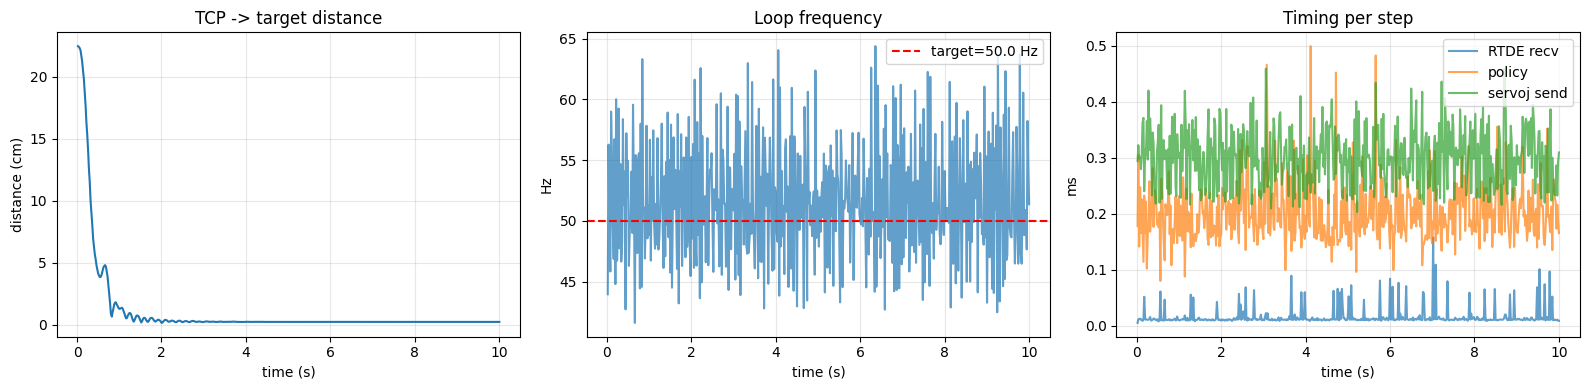

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(df["time"], df["tcp_to_target_dist"] * 100)
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("distance (cm)")
axes[0].set_title("TCP -> target distance"); axes[0].grid(True, alpha=0.3)

axes[1].plot(df["time"], df["loop_hz_true"], alpha=0.7)
axes[1].axhline(CONTROL_HZ, color="r", ls="--", label=f"target={CONTROL_HZ} Hz")
axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("Hz")
axes[1].set_title("Loop frequency"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(df["time"], df["obs_time_s"] * 1000, label="RTDE recv", alpha=0.7)
axes[2].plot(df["time"], df["policy_time_s"] * 1000, label="policy", alpha=0.7)
axes[2].plot(df["time"], df["send_time_s"] * 1000, label="servoj send", alpha=0.7)
axes[2].set_xlabel("time (s)"); axes[2].set_ylabel("ms")
axes[2].set_title("Timing per step"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12 — MuJoCo video replay

In [12]:
mj = robot.mujoco_init_model(
    xml_path=MODEL_PATH,
    height=480, width=640,
    cam_lookat=(0.4, 0.0, 0.4),
    cam_distance=1.8, cam_azimuth=130, cam_elevation=-20,
)

VIDEO_FPS = 30.0
frames, actual_fps = robot.render_video_from_log(mj, df, video_fps=VIDEO_FPS)
media.show_video(frames, fps=actual_fps, height=480)

[render_video_from_log] logged_hz=51.7, stride=2, effective_video_fps=25.9
  Rendered 250 frames from 500 logged steps


This browser does not support the video tag.


## 13 — Frequency analysis

Can the socket-based servoJ command pipeline sustain higher control frequencies?

This section runs the same policy loop at different control rates (10-200 Hz),
each time returning to the start pose first. All results are collected into a
comparison table.

In [18]:
TEST_HZ = [10, 20, 50, 100, 125, 200]

results = {}
for hz in TEST_HZ:
    key = f"{hz}hz"
    print(f"\n{'='*50}")
    print(f"  Running at {hz} Hz")
    print(f"{'='*50}")

    robot.move_to_start(Q_START, a=2.0, v=1.5, timeout_s=15.0, tol=0.01)
    time.sleep(0.5)

    df_run, stats_run = robot.run_policy_loop(
        target_pos=TARGET_POS,
        control_hz=hz,
        timeout_s=TIMEOUT_S,
        action_scale=ACTION_SCALE,
        lookahead_time=LOOKAHEAD_TIME,
        gain=GAIN,
        debug_print=False,
    )
    results[key] = {"df": df_run, "stats": stats_run}
    print(f"  {len(df_run)} steps | achieved {stats_run['mean_loop_hz_true']:.1f} Hz | "
          f"tcp->tgt final={stats_run['final_tcp_to_target_dist']:.4f} m")

print(f"\nDone: {len(results)} runs collected.")


  Running at 10 Hz
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0065  q=[-0.    -1.702  2.248 -2.153 -1.495 -1.501]0 -1.458e+00 -1.505e+00]
  Reached start in 1.62s
  100 steps | achieved 10.0 Hz | tcp->tgt final=0.0021 m

  Running at 20 Hz
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0008  q=[-0.   -1.7   2.25 -2.15 -1.5  -1.5 ]1.497]
  Reached start in 1.22s
  200 steps | achieved 20.1 Hz | tcp->tgt final=0.0022 m

  Running at 50 Hz
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0007  q=[-0.   -1.7   2.25 -2.15 -1.5  -1.5 ]1.497]
  Reached start in 1.22s
  500 steps | achieved 50.7 Hz | tcp->tgt final=0.0022 m

  Running at 100 Hz
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0001  q=[-0.   -1.7   2.25 -2.15 -1.5  -1.5 ]1.497]
  Reached start in 1.21s
  1000 steps | achieved 101.7 Hz | tcp->tgt final=0.0098 m

  Running at 125 Hz
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0013  q=[-1.000e-03 -1.701e+00  2.250e+00 -2.1

### Timing comparison table

| Row | Description |
|-----|-------------|
| `requested_control_hz` | Target loop frequency passed to `run_policy_loop` |
| `true_inferred_frequency_hz` | `num_steps / wall_time` — actual sustained rate |
| `mean_obs_time_s` | Mean time for RTDE `receive_feedback()` + MuJoCo FK |
| `mean_policy_time_s` | Mean time for JIT-compiled policy forward pass |
| `mean_send_time_s` | Mean time for socket `send_servoj()` (URScript on port 30002) |
| `max_obs_time_s / max_policy_time_s / max_send_time_s` | Worst-case per component |
| `mean_tcp_speed_mps` | Mean TCP linear speed from FK positions between steps |
| `max_tcp_speed_mps` | Peak TCP speed observed |

In [19]:
import pandas as pd

rows = [
    "requested_control_hz",
    "true_inferred_frequency_hz",
    "mean_obs_time_s",
    "mean_policy_time_s",
    "mean_send_time_s",
    "max_obs_time_s",
    "max_policy_time_s",
    "max_send_time_s",
    "mean_tcp_speed_mps",
    "max_tcp_speed_mps",
]

table = {}
for key, res in results.items():
    s = res["stats"]
    table[key] = {r: s.get(r) for r in rows}

comp_df = pd.DataFrame(table)

# Format: convert seconds to ms for timing rows
for r in comp_df.index:
    if "_time_s" in r:
        comp_df.loc[r] = comp_df.loc[r] * 1000
        comp_df = comp_df.rename(index={r: r.replace("_time_s", "_time_ms")})

print(comp_df.to_string(float_format="{:.2f}".format))

                            10hz  20hz  50hz  100hz  125hz  200hz
requested_control_hz       10.00 20.00 50.00 100.00 125.00 200.00
true_inferred_frequency_hz  9.90 19.90 49.88  99.89 124.90 199.88
mean_obs_time_ms            0.01  0.01  0.01   0.01   0.01   0.01
mean_policy_time_ms         0.09  0.13  0.09   0.08   0.06   0.05
mean_send_time_ms           0.30  0.32  0.29   0.27   0.25   0.23
max_obs_time_ms             0.03  0.02  0.03   0.03   0.03   0.06
max_policy_time_ms          0.51  7.61  0.18   0.33   0.25   0.21
max_send_time_ms            0.39  3.48  0.88   0.47   0.61   0.41
mean_tcp_speed_mps          0.03  0.04  0.06   0.25   0.41   0.75
max_tcp_speed_mps           0.30  0.49  1.26   2.15   1.96   2.68


### MuJoCo video replays (all runs at 50 fps)

In [20]:
mj_freq = robot.mujoco_init_model(
    xml_path=MODEL_PATH,
    height=480, width=640,
    cam_lookat=(0.4, 0.0, 0.4),
    cam_distance=1.8, cam_azimuth=130, cam_elevation=-20,
)

for key, res in results.items():
    print(f"\n--- {key} ---")
    frames_run, fps_run = robot.render_video_from_log(mj_freq, res["df"], video_fps=50.0)
    media.show_video(frames_run, fps=fps_run, height=360)


--- 10hz ---
[render_video_from_log] logged_hz=10.0, stride=1, effective_video_fps=10.0
  Rendered 100 frames from 100 logged steps


This browser does not support the video tag.



--- 20hz ---
[render_video_from_log] logged_hz=20.1, stride=1, effective_video_fps=20.1
  Rendered 200 frames from 200 logged steps


This browser does not support the video tag.



--- 50hz ---
[render_video_from_log] logged_hz=50.7, stride=1, effective_video_fps=50.7
  Rendered 500 frames from 500 logged steps


...

This browser does not support the video tag.



--- 125hz ---
[render_video_from_log] logged_hz=126.9, stride=3, effective_video_fps=42.3
  Rendered 417 frames from 1250 logged steps


This browser does not support the video tag.



--- 200hz ---
[render_video_from_log] logged_hz=203.6, stride=4, effective_video_fps=50.9
  Rendered 500 frames from 2000 logged steps


This browser does not support the video tag.


## 14 — Robustness test

Run the policy from 4 different starting poses toward 4 different targets at 50 Hz.
All start poses are known-safe keyframes (or small rotations of them).
All targets are within the training workspace: x=[0.3, 0.8], y=[-0.4, 0.4], z=[0.2, 0.8].

In [21]:
ROBUSTNESS_RUNS = [
    {
        "name": "low_home -> center",
        "q_start": [0, -1.7, 2.25, -2.15, -1.5, -1.5],
        "target": [0.5, 0.0, 0.5],
    },
    {
        "name": "task_home -> low-left",
        "q_start": [0.75, -2.2, 1.57, -1.57, -1.57, 0],
        "target": [0.4, -0.2, 0.4],
    },
    {
        "name": "tucked -> far-right",
        "q_start": [0, -2.36, 2.36, -1.57, -1.57, 0],
        "target": [0.6, 0.3, 0.6],
    },
    {
        "name": "low_home_rot -> low-target",
        "q_start": [0.52, -1.7, 2.25, -2.15, -1.5, -1.5],
        "target": [0.35, -0.3, 0.3],
    },
]

robust_results = {}
for run in ROBUSTNESS_RUNS:
    name = run["name"]
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  start q = {np.round(run['q_start'], 2)}")
    print(f"  target  = {run['target']}")
    print(f"{'='*50}")

    robot.move_to_start(run["q_start"], a=2.0, v=1.5, timeout_s=15.0, tol=0.01)
    time.sleep(0.5)

    df_r, stats_r = robot.run_policy_loop(
        target_pos=np.array(run["target"]),
        control_hz=50.0,
        timeout_s=TIMEOUT_S,
        action_scale=ACTION_SCALE,
        lookahead_time=LOOKAHEAD_TIME,
        gain=GAIN,
        debug_print=False,
    )
    robust_results[name] = {"df": df_r, "stats": stats_r, "run": run}
    print(f"  {len(df_r)} steps | final dist={stats_r['final_tcp_to_target_dist']*100:.1f} cm | "
          f"min dist={stats_r['min_tcp_to_target_dist']*100:.1f} cm")

print(f"\nDone: {len(robust_results)} robustness runs.")


  low_home -> center
  start q = [ 0.   -1.7   2.25 -2.15 -1.5  -1.5 ]
  target  = [0.5, 0.0, 0.5]
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0078  q=[-0.003 -1.701  2.248 -2.151 -1.499 -1.494]
  Reached start in 1.62s
  500 steps | final dist=0.2 cm | min dist=0.1 cm

  task_home -> low-left
  start q = [ 0.75 -2.2   1.57 -1.57 -1.57  0.  ]
  target  = [0.4, -0.2, 0.4]
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0000  q=[ 0.75 -2.2   1.57 -1.57 -1.57 -0.  ]0.014]
  Reached start in 2.63s
  500 steps | final dist=0.4 cm | min dist=0.2 cm

  tucked -> far-right
  start q = [ 0.   -2.36  2.36 -1.57 -1.57  0.  ]
  target  = [0.6, 0.3, 0.6]
Moving to start pose with movej (a=2.0, v=1.5)...
  err=0.0000  q=[ 0.   -2.36  2.36 -1.57 -1.57  0.  ]0.007]
  Reached start in 2.42s
  500 steps | final dist=0.3 cm | min dist=0.1 cm

  low_home_rot -> low-target
  start q = [ 0.52 -1.7   2.25 -2.15 -1.5  -1.5 ]
  target  = [0.35, -0.3, 0.3]
Moving to start pose with move

### 2x2 video grid

Each cell shows the MuJoCo replay of one run. The red sphere is the target.

In [25]:
mj_rob = robot.mujoco_init_model(
    xml_path=MODEL_PATH,
    height=360, width=480,
    cam_lookat=(0.4, 0.0, 0.4),
    cam_distance=1.8, cam_azimuth=130, cam_elevation=-20,
)

# Render all runs, pick a representative frame from each (last frame)
run_frames = {}
for name, res in robust_results.items():
    frames_r, fps_r = robot.render_video_from_log(mj_rob, res["df"], video_fps=30.0)
    run_frames[name] = frames_r


# Show all 4 videos sequentially
for name, frames_list in run_frames.items():
    print(f"\n--- {name} ---")
    media.show_video(frames_list, fps=30, height=300)

[render_video_from_log] logged_hz=50.6, stride=2, effective_video_fps=25.3
  Rendered 250 frames from 500 logged steps
[render_video_from_log] logged_hz=50.6, stride=2, effective_video_fps=25.3
  Rendered 250 frames from 500 logged steps
[render_video_from_log] logged_hz=50.6, stride=2, effective_video_fps=25.3
  Rendered 250 frames from 500 logged steps
[render_video_from_log] logged_hz=50.6, stride=2, effective_video_fps=25.3
  Rendered 250 frames from 500 logged steps

--- low_home -> center ---


This browser does not support the video tag.



--- task_home -> low-left ---


This browser does not support the video tag.



--- tucked -> far-right ---


This browser does not support the video tag.



--- low_home_rot -> low-target ---


This browser does not support the video tag.


### TCP-to-target convergence comparison

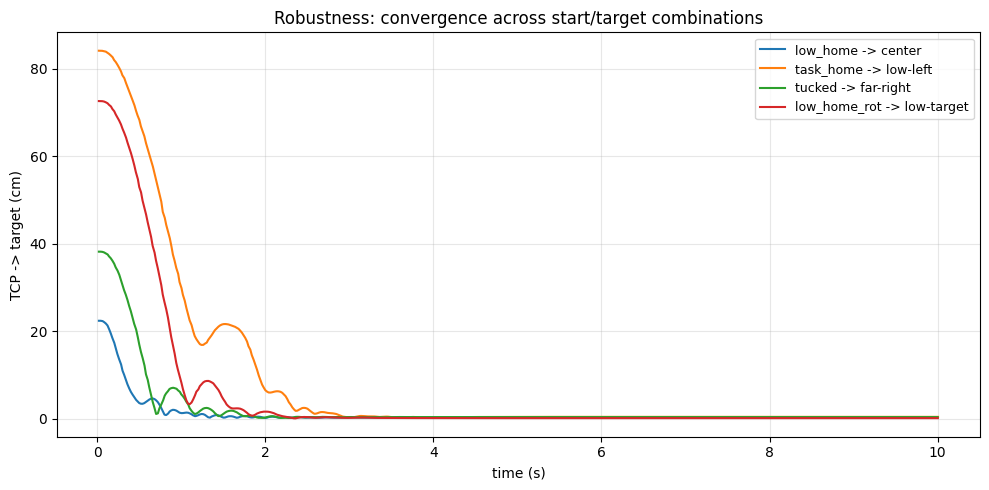

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, res in robust_results.items():
    df_r = res["df"]
    ax.plot(df_r["time"], df_r["tcp_to_target_dist"] * 100, label=name)
ax.set_xlabel("time (s)")
ax.set_ylabel("TCP -> target (cm)")
ax.set_title("Robustness: convergence across start/target combinations")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15 — Disconnect

In [24]:
robot.disconnect()
print("Disconnected.")

Disconnected.
